In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(42)
n_sample=50

data={
    "age":np.random.randint(20,65,size=n_sample),
    "children":np.random.randint(0,4,size=n_sample),
    "married":np.random.choice(["yes","no"],size=n_sample),
    "salary":np.random.randint(30000,150000,size=n_sample)
}

df=pd.DataFrame(data)
# df=df.to_csv("salary.csv",index=False)

In [3]:
df.head()

,age,children,married,salary
0,58,2,no,100592
1,48,3,no,128018
2,34,2,no,143252
3,62,3,yes,38110
4,27,0,yes,109309


In [4]:
df.loc[3,"salary"]=np.nan
df.loc[0,"age"]=np.nan

In [5]:
def fill_median(df,columns):
    for col in columns:
        df[col]=df[col].fillna(df[col].median())
    return df

In [6]:
def encode(df,columns):
    for col in columns:
        df[col]=df[col].map(lambda x: 1 if x=="yes" else 0)
    return df

In [7]:
df=fill_median(df,['age','salary'])
df=encode(df,['married'])

In [8]:
df['age_group']=pd.cut(
    df['age'],
    bins=[18,30,45,60,100],
    labels=["young","adult","middle","senior"]
)
df.head()

,age,children,married,salary,age_group
0,41.0,2,0,100592.0,adult
1,48.0,3,0,128018.0,middle
2,34.0,2,0,143252.0,adult
3,62.0,3,1,110356.0,senior
4,27.0,0,1,109309.0,young


In [9]:
median_salary=df['salary'].median()
df['is_high_income']=[
    1 if s>median_salary else 0
    for s in df['salary']
]
df.head()

,age,children,married,salary,age_group,is_high_income
0,41.0,2,0,100592.0,adult,0
1,48.0,3,0,128018.0,middle,1
2,34.0,2,0,143252.0,adult,1
3,62.0,3,1,110356.0,senior,0
4,27.0,0,1,109309.0,young,0


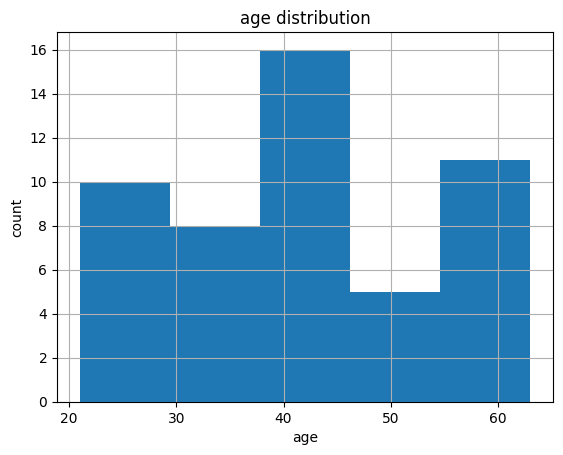

In [10]:
import matplotlib.pyplot as plt
df['age'].hist(bins=5)

plt.title("age distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.show()